In [136]:
import typing

import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.axes

import utils
utils.compatability()

import tikzplotlib


matplotlib.rcParams["savefig.bbox"] = 'tight'
matplotlib.rcParams["pgf.texsystem"] = "pdflatex"

## Setup

In [137]:
# Default parameters
# TODO -- rename them to constants
N = 641
L = np.float64(100.0)
cfl = np.float64(0.5)
advection = np.float64(1.0)
sigma = np.float64(0.8)
max_time = np.float64(50.0)

In [138]:
# Initial conditions

def gaussian_pulse(grid: npt.NDArray[np.floating],
                   center, width) -> npt.NDArray[np.floating]:
    return np.exp(-((grid - center) / width) ** 2)


def square_wave(grid: npt.NDArray[np.floating],
                center, width) -> npt.NDArray[np.floating]:
    return np.where(np.abs(grid - center) <= width, 1.0, 0.0)


def sine_wave(grid: npt.NDArray[np.floating],
              wavenumber: int) -> npt.NDArray[np.floating]:
    return np.sin(wavenumber * grid)


def left_triangle(grid: npt.NDArray[np.floating],
                  l1, l2) -> npt.NDArray[np.floating]:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = (grid[mask] - l1) / (l2 - l1)
    return result


def rectangle(grid: npt.NDArray[np.floating],
              l1, l2) -> npt.NDArray[np.floating]:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = 1.0
    return result


def wave(grid: npt.NDArray[np.floating], l1, l2) -> npt.NDArray[np.floating]:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = 0.5 * (1 - np.cos(2 * np.pi * (grid[mask] - l1) / (l2 - l1)))
    return result


def tooth(grid: npt.NDArray[np.floating],
          l1, l2, l11, l22) -> npt.NDArray[np.floating]:
    result = np.zeros_like(grid)

    mask1 = (grid >= l1) & (grid < l11)
    result[mask1] = -(2/3) * (grid[mask1] - l1) / (l11 - l1) + 1

    mask2 = (grid >= l11) & (grid <= l22)
    result[mask2] = 1/3

    mask3 = (grid > l22) & (grid <= l2)
    result[mask3] = (2/3) * (grid[mask3] - l2) / (l2 - l22) + 1

    return result


def letter_m(grid: npt.NDArray[np.floating],
             l1, l2, l12=None) -> npt.NDArray[np.floating]:
    l12 = l12 or (l1 + l2) / 2.0
    result = np.zeros_like(grid)

    mask1 = (grid >= l1) & (grid < l12)
    result[mask1] = -(2/3) * (grid[mask1] - l1) / (l12 - l1) + 1

    mask2 = (grid >= l12) & (grid <= l2)
    result[mask2] = (2/3) * (grid[mask2] - l2) / (l2 - l12) + 1

    return result


def right_triangle(grid: npt.NDArray[np.floating],
                   l1, l2) -> npt.NDArray[np.floating]:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = (l2 - grid[mask]) / (l2 - l1)
    return result

In [139]:
BoundaryType = typing.Literal['absorbing', 'periodic', 'fixed', 'extrapolation']

def apply_bc(
        u: np.typing.NDArray[np.floating],
        advection: np.typing.NDArray[np.floating] | None = None,
        bc_type: BoundaryType = 'periodic') -> np.typing.NDArray[np.floating]:

    match bc_type:
        case 'absorbing':
            if advection > 0:
                u[0] = 0.0
                u[1] = 0.0
                u[-2] = u[-3]
                u[-1] = u[-2]
            else:
                u[-1] = 0.0
                u[-2] = 0.0
                u[1] = u[2]
                u[0] = u[1]
        case 'periodic':
            u[0] = u[-4]
            u[1] = u[-3]
            u[-2] = u[2]
            u[-1] = u[3]
        case 'fixed':
            u[0] = 0.0
            u[1] = 0.0
            u[-2] = 0.0
            u[-1] = 0.0
        case 'extrapolation':
            if advection > 0:
                u[0] = 0.0
                u[1] = 0.0
                u[-1] = 3.0 * u[-2] - 3.0 * u[-3] + u[-4]
                u[-2] = 3.0 * u[-3] - 3.0 * u[-4] + u[-5]
            else:
                u[-1] = 0.0
                u[-2] = 0.0
                u[0] = 3.0 * u[1] - 3.0 * u[2] + u[3]
                u[1] = 3.0 * u[2] - 3.0 * u[3] + u[4]

    return u

In [140]:
ICFunc = typing.Callable[..., npt.NDArray[np.floating]]


def exact_solution(grid: npt.NDArray[np.floating],
                   ic_func: ICFunc,
                   ic_kwargs: dict,
                   advection: np.floating,
                   time: np.floating,
                   bc_type: BoundaryType,
                   L: np.floating) -> npt.NDArray[np.floating]:
    shifted = grid - advection * time
    if bc_type == "periodic":
        shifted = shifted % L
    return ic_func(shifted, **ic_kwargs)

In [141]:
from mlf_method import mlf_step

# Reload for prototyping and interactivity
import importlib; import mlf_method; importlib.reload(mlf_method); # noqa: E702

In [142]:
def rusanov_step(
    u: npt.NDArray[np.floating], *, cfl: np.floating, **_
) -> npt.NDArray[np.floating]:
    cfl2 = cfl * cfl
    cfl3 = cfl2 * cfl
    omega = (4.0 * cfl2 + 1.0) * (4.0 - cfl2) / 5.0

    u_next = np.zeros_like(u)
    i = np.arange(2, len(u) - 2)
    u_next[i] = (
        u[i]
        - cfl / 12.0 * (-u[i+2] + 8.0*u[i+1] - 8.0*u[i-1] + u[i-2])
        + cfl2 / 8.0 * (u[i+2] - 2.0*u[i] + u[i-2])
        - cfl3 / 12.0 * (u[i+2] - 2.0*u[i+1] + 2.0*u[i-1] - u[i-2])
        - omega / 24.0 * (u[i+2] - 4.0*u[i+1] + 6.0*u[i] - 4.0*u[i-1] + u[i-2])
    )
    return u_next

def lw_step(
    u: npt.NDArray[np.floating], *, cfl: np.floating, **_        
) -> npt.NDArray[np.floating]:
    i = np.arange(1, len(u) - 1)
    u_next = np.zeros_like(u)
    u_next[i] = (
        u[i] 
        - (cfl / 2) * (u[i + 1] - u[i - 1])
        + (cfl**2 / 2) * (u[i + 1] - 2 * u[i] + u[i - 1])
    )
    return u_next


def mlf_with_correction_step(
    u: npt.NDArray[np.floating], *,
    sigma: np.floating, cfl: np.floating, dx: np.floating,
    **_,
) -> npt.NDArray[np.floating]:
    cfl2 = cfl * cfl

    u_next = mlf_step(u, sigma=sigma, cfl=cfl, dx=dx)

    i = np.arange(2, len(u) - 2)
    # Fall back to lower-order scheme at non-smooth points (local extrema)
    oscillation = (u_next[i+1] - u_next[i]) * (u_next[i] - u_next[i-1]) < 0.0
    u_low = (
        sigma * u[i]
        + (1.0 - sigma) * 0.5 * (u[i+1] + u[i-1])
        - 0.5 * cfl * (u[i+1] - u[i-1])
        + 0.5 * cfl2 * (u[i+1] - 2.0 * u[i] + u[i-1])
    )
    u_next[i] = np.where(oscillation, u_low, u_next[i])

    return u_next

In [143]:
StepFunc = typing.Callable[..., npt.NDArray[np.floating]]


def advect(
        step_func: StepFunc, N: int = N, L: np.floating = L, cfl: np.floating = cfl,
        advection: np.floating = advection, sigma: np.floating = sigma,
        max_time: np.floating = max_time, bc_type: BoundaryType = "periodic",
        step_func_kwargs: dict = {},
        ic_func: ICFunc = gaussian_pulse,
        ic_kwargs: dict = {"center": 20.0, "width": 5.0},):
    dx = L / (N - 1.0)
    grid = np.linspace(0.0, (N - 1) * dx, N)

    time = np.float64(0)

    u = ic_func(grid, **ic_kwargs)

    while time <= max_time:
        dt = dx * cfl / advection
        time += dt

        u = apply_bc(u)
        u: npt.NDArray[np.floating] = step_func(u, sigma=sigma, cfl=cfl, dx=dx, a=advection, dt=dt, **step_func_kwargs)

    u_exact = exact_solution(grid, ic_func, ic_kwargs,
                             advection, time, bc_type, L)

    return grid, u, u_exact

In [144]:
grid, u, u_exact = advect(mlf_step)
error = np.abs(u - u_exact)
grid, u_rusanov, u_exact = advect(rusanov_step)
error_rusanov = np.abs(u_rusanov - u_exact)

dx = L / (N - 1.0)

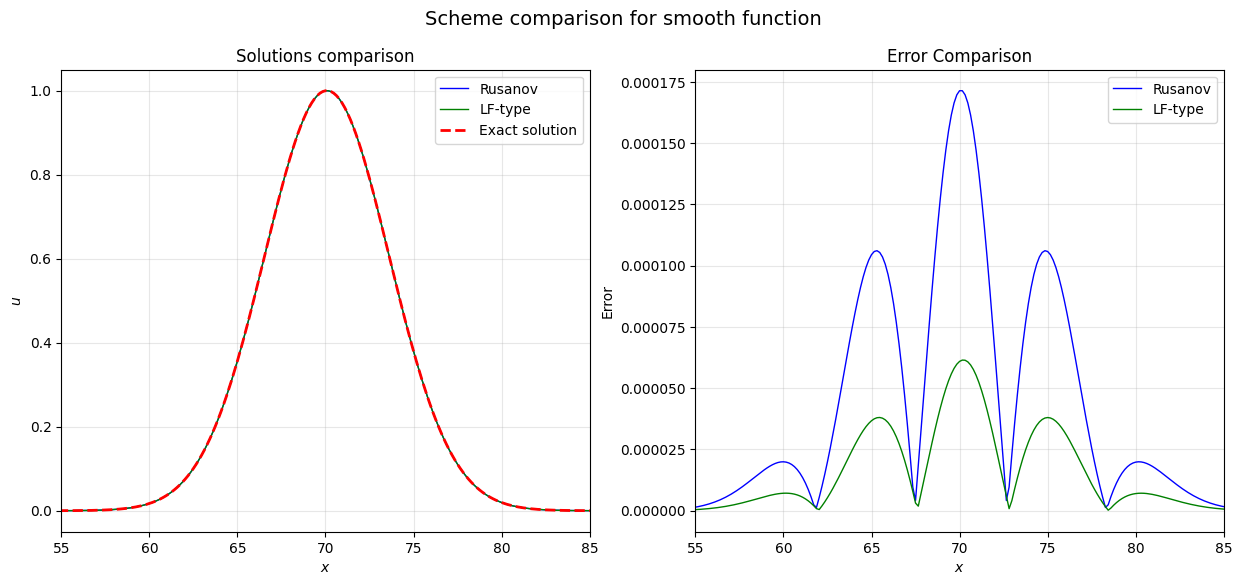

In [145]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(grid, u_rusanov, 'b-', linewidth=1, label='Rusanov')
plt.plot(grid, u, 'g-', linewidth=1, label='LF-type')
plt.plot(grid, u_exact, 'r--', linewidth=2, label='Exact solution')
plt.xlim(55, 85)
# plt.xlim(70 - 0.01, 70 + 0.01)
# plt.ylim(1 - 0.01, 1 + 0.01)
plt.xlabel('$x$')
plt.ylabel('$u$')
plt.title('Solutions comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(grid, error_rusanov, 'b-', linewidth=1, label='Rusanov')
plt.plot(grid, error, 'g-', linewidth=1, label='LF-type')
plt.xlabel('$x$')
plt.xlim(55, 85)
plt.ylabel('Error')
plt.title('Error Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

tikzplotlib.save('scheme-comparison-smooth.tikz', extra_groupstyle_parameters={r'horizontal sep=2cm'})
plt.suptitle('Scheme comparison for smooth function', fontsize=14)
plt.show()

In [146]:
grid, u, u_exact = advect(mlf_step)
error = np.abs(u - u_exact)
grid, u_rusanov, u_exact = advect(rusanov_step)
error_rusanov = np.abs(u_rusanov - u_exact)

dx = L / (N - 1.0)

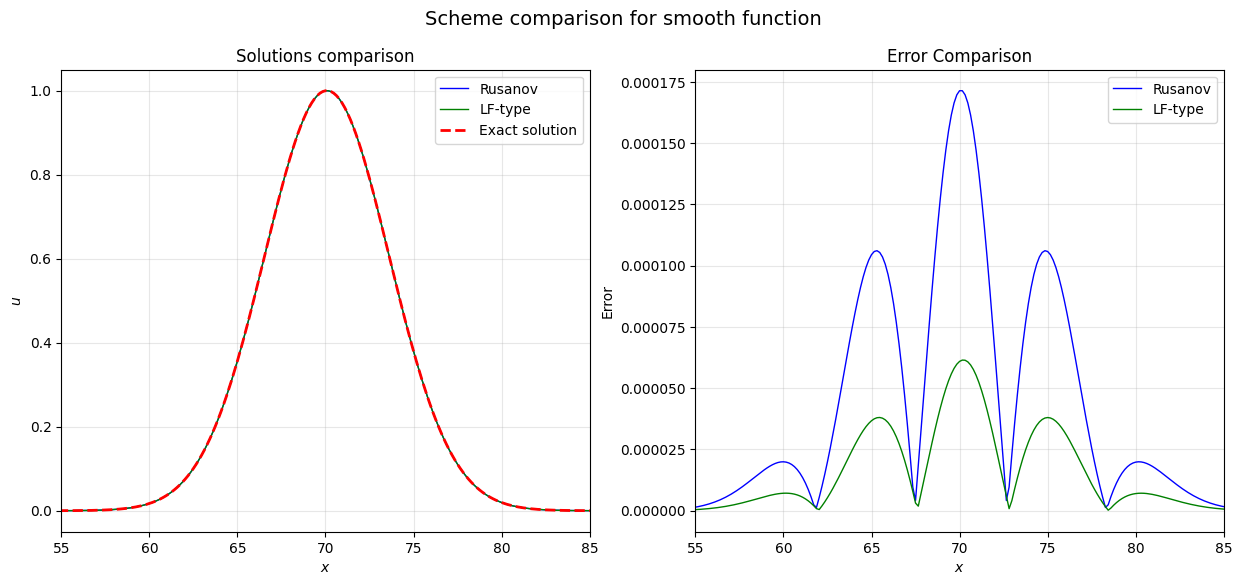

In [147]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(grid, u_rusanov, 'b-', linewidth=1, label='Rusanov')
plt.plot(grid, u, 'g-', linewidth=1, label='LF-type')
plt.plot(grid, u_exact, 'r--', linewidth=2, label='Exact solution')
plt.xlim(55, 85)
# plt.xlim(70 - 0.01, 70 + 0.01)
# plt.ylim(1 - 0.01, 1 + 0.01)
plt.xlabel('$x$')
plt.ylabel('$u$')
plt.title('Solutions comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(grid, error_rusanov, 'b-', linewidth=1, label='Rusanov')
plt.plot(grid, error, 'g-', linewidth=1, label='LF-type')
plt.xlabel('$x$')
plt.xlim(55, 85)
plt.ylabel('Error')
plt.title('Error Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Scheme comparison for smooth function', fontsize=14)
# tikzplotlib.save('scheme-comparison-disconti.tikz')
plt.show()

## Convergence

In [148]:
mesh_sizes = [51, 101, 201, 401, 801, 1601,]
dxs = np.array(L / (np.array(mesh_sizes) - 1))
# ps = (1, 2, np.inf)
ps = (2, np.inf)

In [ ]:
def convergence(
    mesh_sizes: typing.Sequence[int] = mesh_sizes,
    ps: typing.Sequence[float] = ps,
    **kws,
) -> dict[float, np.ndarray]:
    """
    Compute L_p errors for arbitrary p values.

    Returns
    -------
    errors: dict[p, np.ndarray]
        Mapping from p to array of errors (aligned with mesh_sizes).
    """
    def lp_error(error: np.ndarray, p: float) -> np.floating:
        return np.max(error) if p == np.inf \
            else (L * np.mean(np.abs(error)**p))**(1 / p)
    # FIXME -- duplication ^

    errors = {p: np.zeros(len(mesh_sizes)) for p in ps}

    for i, mesh_size in enumerate(mesh_sizes):
        _, u, u_exact = advect(N=mesh_size, **kws)

        error = np.abs(u - u_exact)

        for p in ps:
            errors[p][i] = lp_error(error, p)

    return errors

In [150]:
import matplotlib.axes
import matplotlib.ticker


def plot_convergence(
    dxs: np.ndarray,
    errors: dict[float, np.ndarray],
    expected_order: int,
    axes: typing.Sequence[matplotlib.axes.Axes] | None = None,
    **kws
):
    """
    Plots convergence data for multiple methods across multiple norms.

    Args:
        results: Nested dict {method_name: {p: errors}}.
        dxs: Array of mesh spacings (for the x-axis).
        expected_orders: dict {method_name: theoretical_order}.
        axes: Optional pre-existing axes to plot on.
    """

    if axes is None:
        fig, axes = plt.subplots(1, len(errors), figsize=(5 * len(errors), 4))
        # Place for a suptitle
        fig.set_layout_engine(rect=[0, 0.03, 1, 0.95])
        # Ensure axes is always a list-like object for consistency
        axes = typing.cast(typing.Sequence[matplotlib.axes.Axes],
                           [axes] if len(errors) == 1 else axes)
    else:
        fig = axes[0].figure

    for ax, (p, error) in zip(axes, errors.items(), strict=True):
        ax.loglog(mesh_sizes, error, 'o--', linewidth=2, **kws)

        reference = error[0] * (np.array(dxs) / dxs[0])**expected_order
        ax.loglog(
            mesh_sizes, reference,
            # label=fr'${expected_order}^{{\text{{th}}}}$-''order',
            label=fr'Порядок ${expected_order}$',
            color=ax.lines[-1].get_color(),  # Match color of method
            linestyle=':', linewidth=1.5
        )

        # ax.set_xlabel(r'Mesh size $\propto 1/\Delta x$')
        # ax.set_ylabel('Error')
        ax.set_xlabel(r'Размер сетки $\propto 1/\Delta x$')
        ax.set_ylabel('Ошибка')
        # ax.set_title(r"$L_\infty$ norm" if p == np.inf else f"$L_{int(p)}$" " norm")
        ax.set_title(r"$L_\infty$ норма" if p == np.inf else f"$L_{int(p)}$" " норма")
        ax.legend(loc='lower left')
        ax.grid(True, which='major', alpha=0.3)

        ax.set_xticks(mesh_sizes, minor=False)
        ax.minorticks_off()
        ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

    return fig, axes

In [151]:
dxs = L / np.array(mesh_sizes)

mlf_convergence = convergence(
    step_func=mlf_step, mesh_sizes=mesh_sizes, sigma=0.5, cfl=0.5, max_time=10
)
lw_convergence = convergence(
    step_func=lw_step, mesh_sizes=mesh_sizes, sigma=0.5, cfl=0.5, max_time=10
)

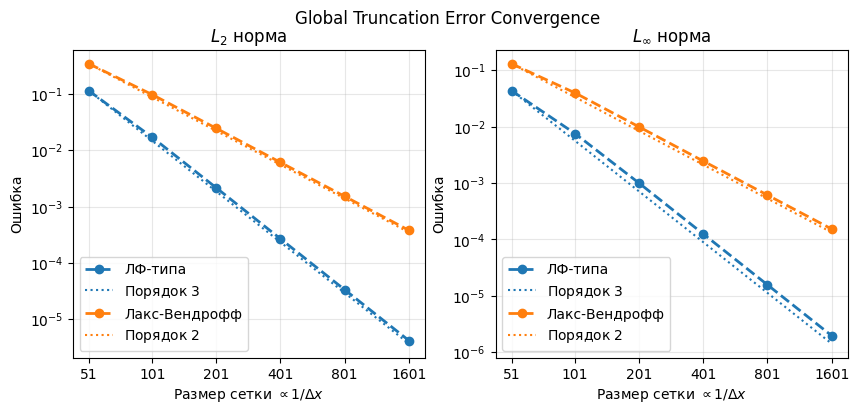

In [152]:
fig, axes = plot_convergence(
    dxs, errors=mlf_convergence, expected_order=3,
    # label="LF-type"
    label="ЛФ-типа"
    )
fig, axes = plot_convergence(
    dxs, errors=lw_convergence, expected_order=2,
    # label="Lax-Wendroff",
    label="Лакс-Вендрофф",
    axes=axes)


tikzplotlib.save('convergence-ge.tikz', axis_width=r"0.48\textwidth", extra_groupstyle_parameters={r'horizontal sep=2cm'})
fig.suptitle("Global Truncation Error Convergence")
plt.show()

In [153]:
print("Mesh size [" + " ".join([f"{size:>6d}" for size in mesh_sizes]) + "]\n")
np.set_printoptions(precision=2)
for method_name, errors in zip(
    ("Lax-Wendroff", "LF-type"),
    (lw_convergence, mlf_convergence)
):
    print(method_name)
    for p, error in errors.items():
        print(f"L_{'inf' if p ==np.inf else p :<7} {np.log2(error)}")
    print()

Mesh size [    51    101    201    401    801   1601]

Lax-Wendroff
L_2       [ -1.54  -3.36  -5.34  -7.35  -9.36 -11.36]
L_inf     [ -2.93  -4.65  -6.65  -8.66 -10.67 -12.67]

LF-type
L_2       [ -3.13  -5.88  -8.85 -11.86 -14.86 -17.87]
L_inf     [ -4.51  -7.04  -9.96 -12.95 -15.96 -18.96]



In [154]:
def convergence_to_latex(mesh_sizes, results, precision=2):
    """
    Convert convergence data into a LaTeX tabular string.

    Parameters
    ----------
    mesh_sizes : iterable
        Column headers (e.g., mesh sizes).
    results : dict[str, dict]
        Mapping from method name to a dict of {norm_p: error_array}.
    precision : int
        Number of decimal places for the numeric entries.

    Returns
    -------
    str
        LaTeX tabular code (requires the `booktabs` package).
    """
    lines = []

    # 1. Header
    col_format = "l l " + "c " * len(mesh_sizes)
    lines.append(f"\\begin{{tabular}}{{{col_format.strip()}}}")
    lines.append("\\toprule")

    # header = "Method & Norm & " + " & ".join(map(str, mesh_sizes)) + " \\\\"
    header = "Схема & Норма & " + " & ".join(map(str, mesh_sizes)) + " \\\\"

    lines.append(header)
    lines.append("\\midrule")

    # 2. Body
    methods = list(results.items())
    for i, (method_name, errors) in enumerate(methods):
        method_label = method_name
        for p, error in errors.items():
            p_label = r'$L_\infty$' if p == np.inf else f'$L_{p}$'
            log_errors = np.log2(error)
            row_vals = " & ".join(
                [f"{val:.{precision}f}" for val in log_errors])
            lines.append(f"{method_label} & {p_label} & {row_vals} \\\\")
            method_label = ""  # Only print method name once per group

        # Separator between methods (but not after the last one)
        if i < len(methods) - 1:
            lines.append("\\midrule")

    # 3. Footer
    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")

    return "\n".join(lines)

In [ ]:
latex_str = convergence_to_latex(mesh_sizes, {
    # "Lax-Wendroff": lw_convergence,
    # "LF-type": mlf_convergence,
    "Лакс-Вендрофф": lw_convergence,
    "ЛФ-типа": mlf_convergence,
})

with open("convergence-ge-table.tex", "w") as f:
    f.write(latex_str)

In [156]:
dxs = L / np.array(mesh_sizes)

mlf_convergence = convergence(
    step_func=mlf_step, mesh_sizes=mesh_sizes, sigma=0.5, cfl=0.5, max_time=0
)
lw_convergence = convergence(
    step_func=lw_step, mesh_sizes=mesh_sizes, sigma=0.5, cfl=0.5, max_time=0
)

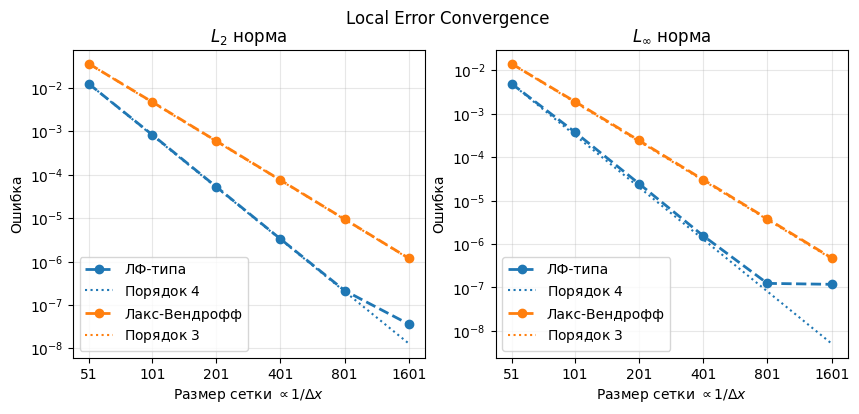

In [157]:
fig, axes = plot_convergence(
    dxs, errors=mlf_convergence, expected_order=4,
    # label="LF-type"
    label="ЛФ-типа"
    )
fig, axes = plot_convergence(
    dxs, errors=lw_convergence, expected_order=3,
    # label="Lax-Wendroff",
    label="Лакс-Вендрофф",
    axes=axes)

tikzplotlib.save('convergence-le.tikz', axis_width=r"0.48\textwidth", extra_groupstyle_parameters={r'horizontal sep=2cm'})
fig.suptitle("Local Error Convergence")
plt.show()

In [158]:
dxs = L / np.array(mesh_sizes)

mlf_convergence = convergence(
    step_func=mlf_step, mesh_sizes=mesh_sizes, sigma=0.99, cfl=0.5, max_time=0
)
lw_convergence = convergence(
    step_func=lw_step, mesh_sizes=mesh_sizes, sigma=0.99, cfl=0.5, max_time=0
)

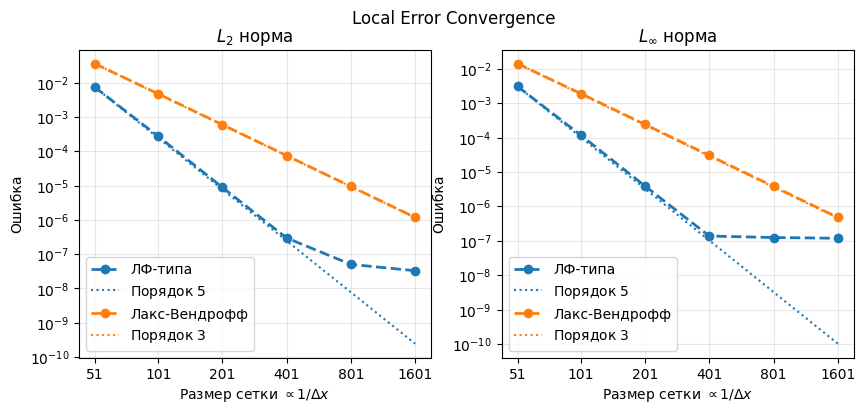

In [159]:
fig, axes = plot_convergence(
    dxs, errors=mlf_convergence, expected_order=5,
    # label="LF-type"
    label="ЛФ-типа"
)
fig, axes = plot_convergence(
    dxs, errors=lw_convergence, expected_order=3,
    label="Лакс-Вендрофф",
    axes=axes)

tikzplotlib.save('convergence-le-diminishing-parameter.tikz', axis_width=r"0.48\textwidth", extra_groupstyle_parameters={r'horizontal sep=2cm'})
fig.suptitle("Local Error Convergence")
plt.show()

In [ ]:
latex_str = convergence_to_latex(mesh_sizes, {
    # "Lax-Wendroff": lw_convergence,
    # "LF-type": mlf_convergence,
    "Лакс-Вендрофф": lw_convergence,
    "ЛФ-типа": mlf_convergence,

})

with open("convergence-le-table.tex", "w") as f:
    f.write(latex_str)

## Monotonization

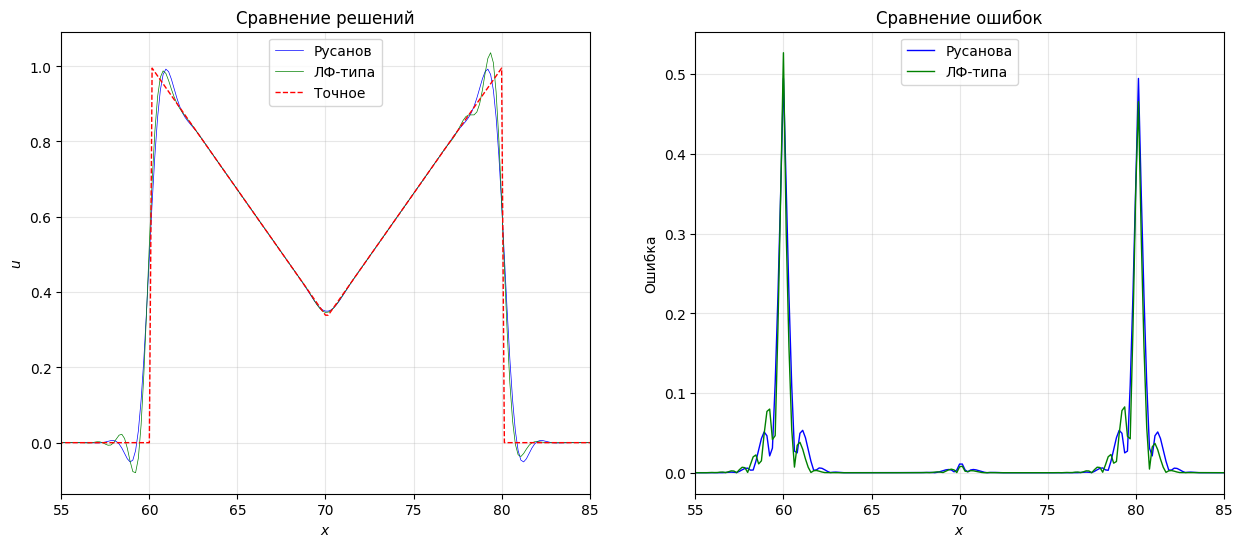

In [ ]:
plt.figure(figsize=(15, 6))

for i, (ic_func, ic_kwargs) in enumerate(
    zip(
        [
            # rectangle,
            # left_triangle,
            letter_m,
            # gaussian_pulse,
        ],
        [
            # {"l1": 10.0, "l2": 30.0},
            # {"l1": 10.0, "l2": 30.0},
            {"l1": 10.0, "l2": 30.0},
            # {"center": 20.0, "width": 5.0},
        ])):
    grid, u, u_exact = advect(
        mlf_step,
        ic_func=ic_func,
        ic_kwargs=ic_kwargs,
    )
    grid, u_rusanov, u_exact = advect(
        rusanov_step,
        ic_func=ic_func,
        ic_kwargs=ic_kwargs,
    )

    plt.subplot(1, 2, 2 * i + 1)

    plt.plot(grid, u_rusanov, 'b-', linewidth=0.5,
            #  label='Rusanov'
            label='Русанов'
)
    plt.plot(grid, u, 'g-', linewidth=0.5, label='ЛФ-типа')
    plt.plot(grid, u_exact, 'r--', linewidth=1, label='Точное')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    plt.ylabel('$u$')
    # plt.title('Solution comparison')
    plt.title('Сравнение решений')
    plt.legend(loc='upper center')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2 * i + 2)
    error_rusanov = np.abs(u_rusanov - u_exact)
    error = np.abs(u - u_exact)

    plt.plot(grid, error_rusanov, 'b-', linewidth=1, label='Русанов')
    plt.plot(grid, error, 'g-', linewidth=1, label='ЛФ-типа')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    # plt.ylabel('Error')
    plt.ylabel('Ошибка')

    # plt.title('Error Comparison')
    plt.title('Сравнение ошибок')
    plt.legend(loc='upper center')
    plt.grid(True, alpha=0.3)

tikzplotlib.save('scheme-comparison-discontinuous.tikz', axis_width=r'0.5\textwidth', extra_groupstyle_parameters={r'horizontal sep=2cm'})
plt.show()

In [169]:
def sign_change_sensor(u: np.ndarray) -> np.ndarray:
    """
    Simplest sign-change sensor:
    marks cells where (u_{i+1} - u_i)*(u_i - u_{i-1}) < 0.
    Returns a boolean mask of length len(u)-2.
    """
    diff_r = u[1:] - u[:-1]          # length N-1
    diff_l = u[:-1] - u[:-1]          # just a placeholder, we need aligned arrays
    product = diff_r[1:] * diff_r[:-1]  # (u_{i+1}-u_i)*(u_i - u_{i-1})
    return (product < 0).astype(float)


def curvature_sensor(u: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Returns S_i (len(u)-2) for interior cells i=1..n-2."""
    im1, i, ip1 = slice(0,-2), slice(1,-1), slice(2,None)
    num = np.abs(u[im1] - 2.0*u[i] + u[ip1])
    den = np.abs(u[im1] - u[i]) + np.abs(u[i] - u[ip1]) + eps
    return num / den

def local_variation_sensor(u: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Wider stencil, len(u)-4 for cells 2..n-3."""
    idx = np.arange(2, len(u)-2)
    num = np.abs(u[idx+1] - 2.0*u[idx] + u[idx-1])
    den = (np.abs(u[idx+2] - u[idx+1]) + np.abs(u[idx+1] - u[idx]) +
           np.abs(u[idx] - u[idx-1]) + np.abs(u[idx-1] - u[idx-2]) + eps)
    S = 1.0 - num/den
    return np.clip(S, 0.0, 1.0)

def hode_sensor(u: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """High‑order derivative sensor, len(u)-4."""
    idx = np.arange(2, len(u)-2)
    d3a = np.abs(u[idx+2] - 3.0*u[idx+1] + 3.0*u[idx] - u[idx-1])
    d3b = np.abs(u[idx+1] - 3.0*u[idx] + 3.0*u[idx-1] - u[idx-2])
    var = np.abs(u[idx+1] - u[idx-1]) + eps
    S = 1.0 / (1.0 + (d3a + d3b) / var)
    return np.clip(S, 0.0, 1.0)

# TODO -- Add WENO smoothness indicator

def pad_sensor(S_partial: np.ndarray, n: int) -> np.ndarray:
    """Extend interior sensor to full length n."""
    m = len(S_partial)
    if m == n: return S_partial
    S_full = np.zeros(n)
    if m == n-2:        # from curvature_sensor
        S_full[1:-1] = S_partial
        S_full[0], S_full[-1] = S_partial[0], S_partial[-1]
    elif m == n-4:      # from local_variation/hode
        S_full[2:-2] = S_partial
        S_full[0] = S_full[1] = S_partial[0]
        S_full[-1] = S_full[-2] = S_partial[-1]
    else:
        raise ValueError(f"Sensor length {m} unexpected for n={n}")
    return S_full

### Adaptive Artificial Viscosity

In [170]:
def aav_step(
    u: np.ndarray,
    dx: float, cfl: float, sigma: float, a: float,
    sensor: typing.Callable = curvature_sensor,
    mu_factor_min: float = 0.01,
    mu_factor_max: float = 0.45,
    **mlf_args
) -> np.ndarray:
    dt = cfl * dx / np.abs(a)
    mu_max = mu_factor_max * dx**2 / dt
    mu_min = mu_factor_min * mu_max

    u_pred = mlf_step(u, dx=dx, cfl=cfl, sigma=sigma, **mlf_args)

    S_partial = sensor(u_pred)
    S = pad_sensor(S_partial, len(u_pred))

    mu = mu_min + (mu_max - mu_min) * (1.0 - S)

    u_new = u_pred.copy()
    n = len(u)
    for i in range(1, n - 1):
        flux_right = mu[i] * (u_pred[i + 1] - u_pred[i])
        flux_left = mu[i - 1] * (u_pred[i] - u_pred[i - 1])
        u_new[i] += (dt / dx**2) * (flux_right - flux_left)
    return u_new

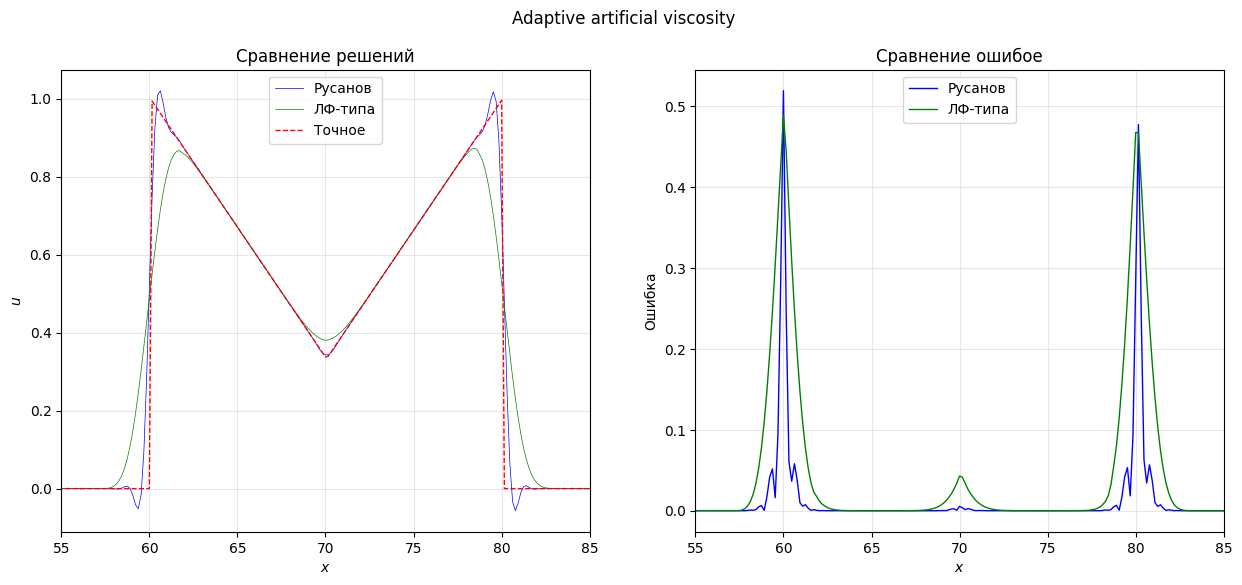

In [171]:
plt.figure(figsize=(15, 6))

for i, (ic_func, ic_kwargs) in enumerate(
    zip(
        [
            # rectangle,
            # left_triangle,
            letter_m,
            # gaussian_pulse,
        ],
        [
            # {"l1": 10.0, "l2": 30.0},
            # {"l1": 10.0, "l2": 30.0},
            {"l1": 10.0, "l2": 30.0},
            # {"center": 20.0, "width": 5.0},
         ])):
    grid, u, u_exact = advect(
            aav_step,
            step_func_kwargs=dict(    mu_factor_min = 0.01, mu_factor_max = 0.05,),
            cfl=0.9,
            sigma=0.9,
            ic_func=ic_func,
            ic_kwargs=ic_kwargs,
        )
    grid, u_rusanov, u_exact = advect(
            rusanov_step,
            cfl=0.9,
            sigma=0.9,
            ic_func=ic_func,
            ic_kwargs=ic_kwargs,
        )

    plt.subplot(1, 2, 2 * i + 1)

    plt.plot(grid, u_rusanov, 'b-', linewidth=0.5, label='Русанов')
    plt.plot(grid, u, 'g-', linewidth=0.5, label='ЛФ-типа')
    plt.plot(grid, u_exact, 'r--', linewidth=1, label='Точное')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    plt.ylabel('$u$')
    plt.title('Сравнение решений')
    plt.legend(loc='upper center')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2 * i + 2)
    error_rusanov = np.abs(u_rusanov - u_exact)
    error = np.abs(u - u_exact)

    plt.plot(grid, error_rusanov, 'b-', linewidth=1, label='Русанов')
    plt.plot(grid, error, 'g-', linewidth=1, label='ЛФ-типа')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    # plt.ylabel('Error')
    plt.ylabel('Ошибка')
    plt.title('Сравнение ошибое')
    plt.legend(loc='upper center')
    plt.grid(True, alpha=0.3)

tikzplotlib.save('adaptive-artificial-viscosity.tikz', axis_width=r'0.5\textwidth', extra_groupstyle_parameters={r'horizontal sep=2cm'})
plt.suptitle("Adaptive artificial viscosity")
plt.show()

In [172]:
def low_order_step(u: np.ndarray, cfl: float, sigma: float) -> np.ndarray:
    cfl2 = cfl * cfl
    i = np.arange(1, len(u)-1)
    u_low = (
        sigma * u[i]
        + (1.0 - sigma) * 0.5 * (u[i+1] + u[i-1])
        - 0.5 * cfl * (u[i+1] - u[i-1])
        + 0.5 * cfl2 * (u[i+1] - 2.0 * u[i] + u[i-1])
    )
    # keep boundaries unchanged
    u_new = u.copy()
    u_new[1:-1] = u_low
    return u_new

### Hybrid schemes

The local viscosity coefficient $\nu_i$ is chosen using a shock sensor. The discrete equation becomes

$$
u_i^{n+1} = u_i^{\text{HO}} + \frac{\Delta t}{\Delta x}\Bigl(F^{\nu}_{i+1/2} - F^{\nu}_{i-1/2}\Bigr),
\qquad
F^{\nu}_{i+1/2} = \nu_{i+1/2}\,\frac{u_{i+1}-u_i}{\Delta x}.
$$

Conservation is guaranteed because the viscous term is in flux form. Stability requires $\frac{2\Delta t}{\Delta x^2}\max(\nu)\le 1$. For $\nu \sim C\,\Delta x\,|a|$ this becomes $C\,\mathrm{CFL}\le \tfrac12$, which is easily satisfied for CFL ≤ 1 with $C=0.5$.

The scheme preserves conservation and can probably be proven to (TVB) if the ramp ensures that near shocks the flux becomes purely upwind

Sensor $S_i$ returns 0 at a discontinuity, 1 in completely smooth regions.
Blending weight $w_i$ is a ramped version of $S_i$, so the transition can be made sharper or smoother.

Blended update then look like
  $$u_i^{n+1} = w_i \, u_i^{\text{high}} + (1-w_i) \, u_i^{\text{low}}.$$

In [173]:
def low_order_upwind(u: np.ndarray, cfl: float, a: float, **_) -> np.ndarray:
    n = len(u)
    u_new = u.copy()
    v = abs(a)
    if a >= 0:
        for i in range(1, n - 1):
            u_new[i] = u[i] - cfl * (u[i] - u[i - 1])
    else:
        for i in range(1, n - 1):
            u_new[i] = u[i] - cfl * (u[i + 1] - u[i])
    return u_new

In [174]:
def hybrid_mlf_step(
    u: np.ndarray,
    dx: float, cfl: float, sigma: float, a: float,
    sensor: typing.Callable = curvature_sensor,
    sensor_ramp: typing.Callable = lambda s: s**2,
    low_step=low_order_upwind,
    **mlf_kwargs
) -> np.ndarray:
    # High‑order update
    u_high = mlf_step(u, dx=dx, cfl=cfl, sigma=sigma, **mlf_kwargs)

    # Low‑order update
    u_low = low_step(u, cfl=cfl, sigma=sigma, a=a)

    # Sensor and blending weight
    S_partial = sensor(u)
    S = pad_sensor(S_partial, len(u))
    w = np.clip(sensor_ramp(S), 0.0, 1.0)

    u_new = u_high.copy()
    i_interior = slice(2, len(u) - 2)
    u_new[i_interior] = (
        w[i_interior] * u_high[i_interior]
        + (1.0 - w[i_interior]) * u_low[i_interior]
    )
    return u_new

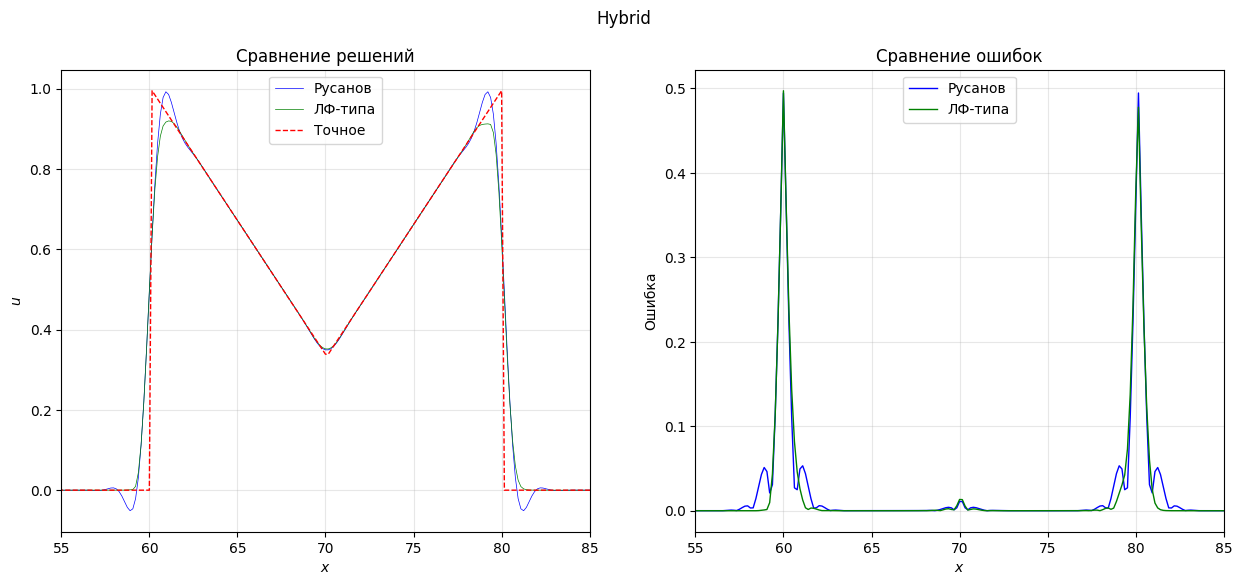

In [ ]:
plt.figure(figsize=(15, 6))

for i, (ic_func, ic_kwargs) in enumerate(
    zip(
        [
            # rectangle,
            # left_triangle,
            letter_m,
            # gaussian_pulse,
        ],
        [
            # {"l1": 10.0, "l2": 30.0},
            # {"l1": 10.0, "l2": 30.0},
            {"l1": 10.0, "l2": 30.0},
            #  {"center": 20.0, "width": 5.0},
        ])):
    grid, u, u_exact = advect(
        hybrid_mlf_step,
        step_func_kwargs=dict(sensor=hode_sensor,
                              sensor_ramp=lambda s: np.clip(4*s-1, 0, 1)),
        ic_func=ic_func,
        ic_kwargs=ic_kwargs,
    )
    grid, u_rusanov, u_exact = advect(
        rusanov_step,
        ic_func=ic_func,
        ic_kwargs=ic_kwargs,
    )

    plt.subplot(1, 2, 2 * i + 1)

    plt.plot(grid, u_rusanov, 'b-', linewidth=0.5, label='Русанов')
    plt.plot(grid, u, 'g-', linewidth=0.5, label='ЛФ-типа')
    plt.plot(grid, u_exact, 'r--', linewidth=1, label='Точное')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    plt.ylabel('$u$')
    plt.title('Сравнение решений')
    plt.legend(loc='upper center')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2 * i + 2)
    error_rusanov = np.abs(u_rusanov - u_exact)
    error = np.abs(u - u_exact)

    plt.plot(grid, error_rusanov, 'b-', linewidth=1, label='Русанов')
    plt.plot(grid, error, 'g-', linewidth=1, label='ЛФ-типа')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    # plt.ylabel('Error')
    plt.ylabel('Ошибка')
    plt.title('Сравнение ошибок')
    plt.legend(loc='upper center')
    plt.grid(True, alpha=0.3)

tikzplotlib.save('hybrid.tikz', axis_width=r'0.5\textwidth', extra_groupstyle_parameters={r'horizontal sep=2cm'})
# tikzplotlib.save('hybrid.pgf')

plt.suptitle("Hybrid")
plt.show()

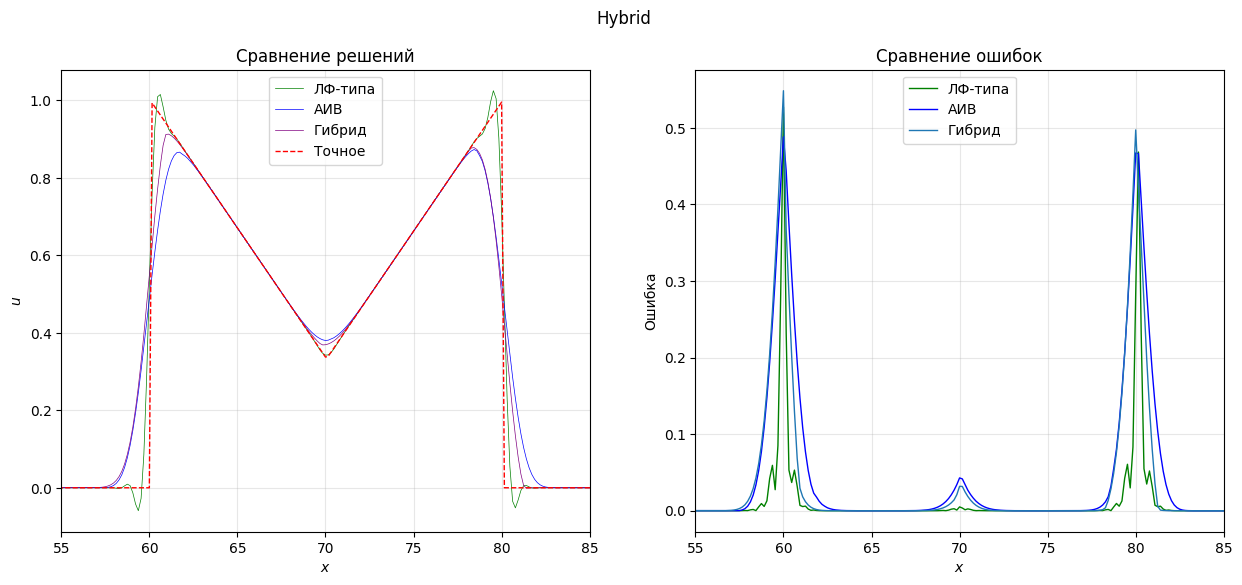

In [ ]:
plt.figure(figsize=(15, 6))

for i, (ic_func, ic_kwargs) in enumerate(
    zip(
        [
            # rectangle,
            # left_triangle,
            letter_m,
            # gaussian_pulse,
        ],
        [
            # {"l1": 10.0, "l2": 30.0},
            # {"l1": 10.0, "l2": 30.0},
            {"l1": 10.0, "l2": 30.0},
            #  {"center": 20.0, "width": 5.0},
        ])):
    grid, u, u_exact = advect(
        mlf_step,
        cfl=0.9,
        sigma=0.9,

        ic_func=ic_func,
        ic_kwargs=ic_kwargs,
    )

    grid, u_hybrid, u_exact = advect(
        hybrid_mlf_step,
        cfl=0.9,
        sigma=0.9,

        step_func_kwargs=dict(sensor=curvature_sensor),
        ic_func=ic_func,
        ic_kwargs=ic_kwargs,
    )
    grid, u_aav, u_exact = advect(
        aav_step,
        step_func_kwargs=dict(    mu_factor_min = 0.01, mu_factor_max = 0.05,),
        cfl=0.9,
        sigma=0.9,
        ic_func=ic_func,
        ic_kwargs=ic_kwargs,
    )

    plt.subplot(1, 2, 2 * i + 1)

    plt.plot(grid, u, 'g-', linewidth=0.5, label='ЛФ-типа')
    plt.plot(grid, u_aav, 'b-', linewidth=0.5, label='АИВ')
    plt.plot(grid, u_hybrid, '-', color='purple', linewidth=0.5, label='Гибрид')
    plt.plot(grid, u_exact, 'r--', linewidth=1, label='Точное')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    plt.ylabel('$u$')
    plt.title('Сравнение решений')
    plt.legend(loc='upper center')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2 * i + 2)
    error = np.abs(u - u_exact)
    error_aav = np.abs(u_aav - u_exact)
    error_hybrid = np.abs(u_hybrid - u_exact)

    plt.plot(grid, error, 'g-', linewidth=1, label='ЛФ-типа')    
    plt.plot(grid, error_aav, 'b-', linewidth=1, label='АИВ')
    plt.plot(grid, error_hybrid, '-', linewidth=1, label='Гибрид')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    # plt.ylabel('Error')
    plt.ylabel('Ошибка')
    plt.title('Сравнение ошибок')
    plt.legend(loc='upper center')
    plt.grid(True, alpha=0.3)

tikzplotlib.save('monotization-comparison.tikz', axis_width=r'0.5\textwidth', extra_groupstyle_parameters={r'horizontal sep=2cm'})
# tikzplotlib.save('hybrid.pgf')

plt.suptitle("Сравнение способов монотинзации")
plt.show()

In [221]:
from typing import Dict, Tuple, Any, Iterable, Optional, Callable

def compute_global_errors(
    profiles: Dict[str, Tuple[Callable, Dict[str, Any]]],
    schemes: Dict[str, Tuple[Callable, Dict[str, Any]]],
    sensors: Dict[str, Dict[str, Any]],
    *,
    p: float = 2.0,
    advection_params: Optional[Dict[str, Any]] = None,
    dom_len: float = 100.0,
    sensorless_schemes: Optional[Iterable[str]] = None
) -> Dict[str, Dict[str, float]]:
    """
    Returns nested dict: results[scheme_sensor] = error.
    For schemes listed in sensorless_schemes the key is just the scheme name
    and no sensor column is filled.
    """
    if sensorless_schemes is None:
        sensorless_schemes = set()
    else:
        sensorless_schemes = set(sensorless_schemes)

    if advection_params is None:
        advection_params = dict(N=641, L=100.0, cfl=0.5, advection=1.0,
                                sigma=0.8, max_time=50.0)

    results = {}
    for scheme_name in sorted(schemes.keys()):
        step_func, base_kw = schemes[scheme_name]

        if scheme_name in sensorless_schemes:
            # single row, empty sensor field
            results[scheme_name] = {}
            step_kwargs = base_kw.copy()
            for prof_name in sorted(profiles.keys()):
                ic_func, ic_kw = profiles[prof_name]
                grid, u_num, u_exact = advect(
                    step_func=step_func,
                    ic_func=ic_func,
                    ic_kwargs=ic_kw,
                    step_func_kwargs=step_kwargs,
                    **advection_params
                )
                err = lp_error(np.abs(u_num - u_exact), p=p)
                results[scheme_name][prof_name] = err
        else:
            for sensor_name in sorted(sensors.keys()):
                sensor_kw = sensors[sensor_name]
                row_key = f"{scheme_name} × {sensor_name}"
                results[row_key] = {}
                step_kwargs = base_kw.copy()
                step_kwargs.update(sensor_kw)

                for prof_name in sorted(profiles.keys()):
                    ic_func, ic_kw = profiles[prof_name]
                    grid, u_num, u_exact = advect(
                        step_func=step_func,
                        ic_func=ic_func,
                        ic_kwargs=ic_kw,
                        step_func_kwargs=step_kwargs,
                        **advection_params
                    )
                    err = lp_error(np.abs(u_num - u_exact), p=p)
                    results[row_key][prof_name] = err

    return results


def dict_to_latex_hierarchical(
    data: Dict[str, Dict[str, float]],
    float_format: str = "%.4e",
    rule_after_scheme: bool = True
) -> str:
    """
    Columns: Scheme | Sensor | profile1 | profile2 | ...
    Each scheme name appears once (multirow), followed by one row per sensor.
    Schemes without a sensor use an empty sensor field and appear as a single row.
    """
    # Parse compound keys: "Scheme × Sensor" or "Scheme" (sensorless)
    scheme_sensor_pairs = []
    for compound, prof_errors in data.items():
        if " × " in compound:
            scheme, sensor = compound.split(" × ", 1)
        else:
            scheme, sensor = compound, ""
        scheme_sensor_pairs.append((scheme, sensor, prof_errors))

    # Determine order: group by scheme, then sensor alphabetically (empty first)
    scheme_order = sorted(set(s for s, _, _ in scheme_sensor_pairs))
    sensor_order = sorted(set(sn for _, sn, _ in scheme_sensor_pairs))

    # Build lookup: (scheme, sensor) -> profile_errors dict
    lookup = {}
    for s, sn, errs in scheme_sensor_pairs:
        lookup[(s, sn)] = errs

    # All profile names (columns)
    profile_names = sorted(set(pn for errs in lookup.values() for pn in errs))

    lines = []
    header_cells = ["Схема", "Сенсор"] + profile_names
    lines.append(" & ".join(header_cells) + r" \\ \hline")

    for scheme in scheme_order:
        # sensor rows for this scheme, preserving order (empty first if present)
        sensors_in_scheme = [sn for sn in sensor_order if (scheme, sn) in lookup]
        nrows = len(sensors_in_scheme)
        for i, sensor in enumerate(sensors_in_scheme):
            errs = lookup[(scheme, sensor)]
            if i == 0:
                scheme_cell = rf"{{{scheme}}}"
            else:
                scheme_cell = ""

            # escape underscores if sensor name not empty
            sensor_esc = sensor.replace("_", r"\_") if sensor else ""
            row_cells = [scheme_cell, sensor_esc]
            for pn in profile_names:
                val = errs.get(pn)
                if val is None:
                    row_cells.append("")
                else:
                    row_cells.append(float_format % val)
            lines.append(" & ".join(row_cells) + r" \\")
        if rule_after_scheme:
            lines.append(r"\hline")

    if rule_after_scheme and lines and lines[-1] == r"\hline":
        lines.pop()

    body = "\n".join(lines)
    col_format = "ll" + "X" * len(profile_names)
    tabular = (r"\begin{tabularx}{\textwidth}{" + col_format + "}\n" +
               body + "\n" +
               r"\end{tabularx}")
    return tabular

def save_latex_tabular(data: Dict[str, Dict[str, float]],
                       filename: str,
                       float_format: str = "%.4e"):
    """Write the plain LaTeX hierarchical tabular to a file."""
    tex = dict_to_latex_hierarchical(data, float_format)
    with open(filename, "w", encoding="utf-8") as f:
        f.write(tex)
    print(f"Hierarchical LaTeX tabular saved to {filename}")

# ---------------------------------------------------------------------------
# 6) Example usage
# ---------------------------------------------------------------------------

# Profiles
profiles = {
    r"Гауссовский \mbox{импульс}": (gaussian_pulse, {"center": 20.0, "width": 5.0}),
    r"Квадрат": (square_wave, {"center": 20.0, "width": 5.0}),
    r"Буква <<M>>": (letter_m, {"l1": 10.0, "l2": 30.0}),
    r"Левый \mbox{треугольник}": (left_triangle, {"l1": 10.0, "l2": 30.0}),
    r"Правый \mbox{треугольник}": (right_triangle, {"l1": 10.0, "l2": 30.0}),
}

# Schemes (replace with your actual step functions)
schemes = {
    "Русанов": (rusanov_step, {}),
    "ЛФ-типа": (mlf_step, {}),
    "Гибридная": (hybrid_mlf_step, {},
                        # {"sensor_ramp": lambda s: np.clip(4*s-1, 0, 1)}
                        ),
    "АИВ": (aav_step, {})
}

# Sensors
sensors = {
    r"$S^{\text{cur}}$": {"sensor": curvature_sensor},
    r"$S^{\text{var}}$": {"sensor": local_variation_sensor},
    r"$S^{\text{grad}}$": {"sensor": sign_change_sensor},
}

errors = compute_global_errors(
    profiles=profiles,
    schemes=schemes,
    sensors=sensors,
    sensorless_schemes=['Русанов', "ЛФ-типа"],
    p=2.0,
    # dom_len=100.0
)

save_latex_tabular(errors, "hybrid-global-erros.tex")

Hierarchical LaTeX tabular saved to hybrid-global-erros.tex


In [214]:
errors

{'АИВ × $S^{\\text{cur}}$': {'Буква <<M>>': np.float64(6.260373912075156),
  'Гауссовский \\mbox{импульс}': np.float64(3.1651328039505655),
  'Квадрат': np.float64(5.884391188180002),
  'Левый \\mbox{треугольник}': np.float64(3.298595919326351),
  'Правый \\mbox{треугольник}': np.float64(3.3011922183353635)},
 'АИВ × $S^{\\text{grad}}$': {'Буква <<M>>': np.float64(6.326534897915259),
  'Гауссовский \\mbox{импульс}': np.float64(3.194629163199753),
  'Квадрат': np.float64(5.958675173467024),
  'Левый \\mbox{треугольник}': np.float64(3.3341394765058796),
  'Правый \\mbox{треугольник}': np.float64(3.3354852846792467)},
 'АИВ × $S^{\\text{var}}$': {'Буква <<M>>': np.float64(1.6367450406172595),
  'Гауссовский \\mbox{импульс}': np.float64(0.1304277239436558),
  'Квадрат': np.float64(1.500064937772894),
  'Левый \\mbox{треугольник}': np.float64(0.7975222355513061),
  'Правый \\mbox{треугольник}': np.float64(0.7924724434100366)},
 'Гибридная × $S^{\\text{cur}}$': {'Буква <<M>>': np.float64(3.0